In [33]:
# import required libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [34]:
#load data
data = pd.read_csv("Heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [35]:
# define data
x = data[["age", "sex", "chol"]]
y = data["target"]

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in x.columns:
    if x[column].dtype=="O":
        x[column] = le.fit_transform(x[column]).astype(int)
        
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     1025 non-null   int64
 1   sex     1025 non-null   int64
 2   chol    1025 non-null   int64
dtypes: int64(3)
memory usage: 24.2 KB


In [37]:
# split data to train and test 
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, stratify = y)


In [38]:
RFmodel = RandomForestClassifier(random_state = 42)
import time 
initial_time = time.time()
RFmodel.fit(x_train, y_train)
y_pred = RFmodel.predict(x_test)
end_time = time.time()
time_taken = end_time - initial_time
joblib.dump(RFmodel, "RFmodel.pkl")
print("Running time using Random forest :" , time_taken)

Running time using Random forest : 0.07718515396118164


In [39]:
start_time2 = time.time()
import joblib
rf = joblib.load("discussion.pkl")
rf.predict(x_test)
end_time2 = time.time()
time_taken2 = end_time2 - start_time2
print("Running time using joblib : ", time_taken2)

Running time using joblib :  0.017392873764038086


Text(0.5, 1.0, 'Running time')

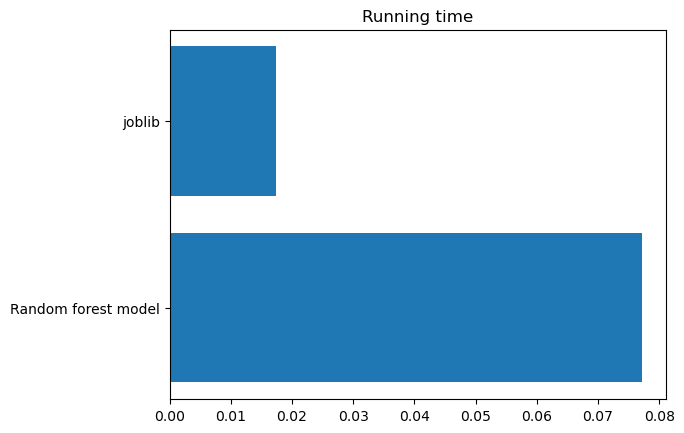

In [40]:
plt.barh(["Random forest model", "joblib"],[time_taken,time_taken2])
plt.title("Running time")

Interpretation: The bar chart compares the running times of two processes: joblib and Random forest model. The x-axis represents the time taken, while the y-axis labels the two methods. The "Random forest model" takes significantly longer than "joblib." This suggests that using joblib for parallel processing reduces execution time. The chart highlights the efficiency advantage of joblib in handling computations.

Text(0.5, 1.0, 'Feature Importance')

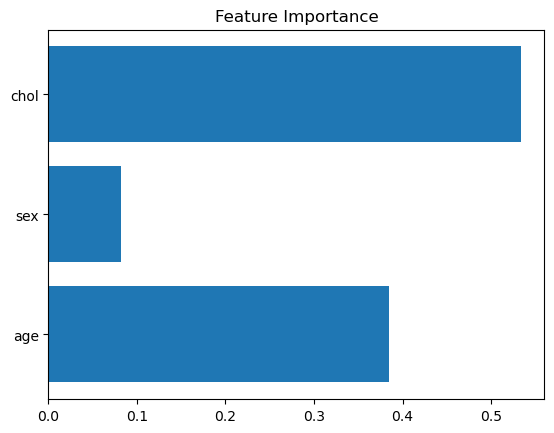

In [41]:
plt.barh(x.columns, rf.feature_importances_)
plt.title("Feature Importance")

Interpretation:The chart shows the importance of different features in a model. "Chol" (cholesterol) is the most important feature. "Age" is also important but less than cholesterol. "Sex" has the least impact on the model. This means cholesterol and age play a bigger role in predictions.

In [45]:
rf = joblib.load("RFmodel.pkl")

pred =  rf.predict(x_test)
pred

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1])

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_accuracy = accuracy_score(y_test, pred)
conf_matrix = confusion_matrix(y_test, pred)
class_report = classification_report(y_test, pred)
print(test_accuracy)
print(conf_matrix)
print(class_report)

0.9804878048780488
[[100   0]
 [  4 101]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       100
           1       1.00      0.96      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



Interpretation:The model has a high accuracy of 98%, meaning it makes very few mistakes. The confusion matrix shows that out of 205 test cases, only 4 were misclassified. Precision and recall values are also high, close to 1, indicating strong performance. The F1-score, which balances precision and recall, is also 0.98, confirming reliability. Overall, the model performs very well with minimal errors.